<a href="https://colab.research.google.com/github/abhinav7667/Abhinav_Kumar_Mishra_2410030515_IILM-GN/blob/main/Detection_of_Plant_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -O "Dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"
!unzip Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [ ]:
!pip install -q tensorflow split-folders

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import splitfolders

In [ ]:
splitfolders.ratio(
    '/content/Plant_leave_diseases_dataset_with_augmentation',
    output="dataset",
    seed=1337,
    ratio=(.8, .1, .1)
)

Copying files: 61486 files [00:40, 1534.44 files/s]


In [ ]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"

BATCH_SIZE = 32
IMG_SIZE = (128, 128)   # smaller = faster

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names

Found 49179 files belonging to 39 classes.
Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


In [ ]:
# Use SMALL subset for fast training
train_dataset = train_dataset.take(300)
val_dataset = val_dataset.take(100)

# Cache + prefetch (speed boost)
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

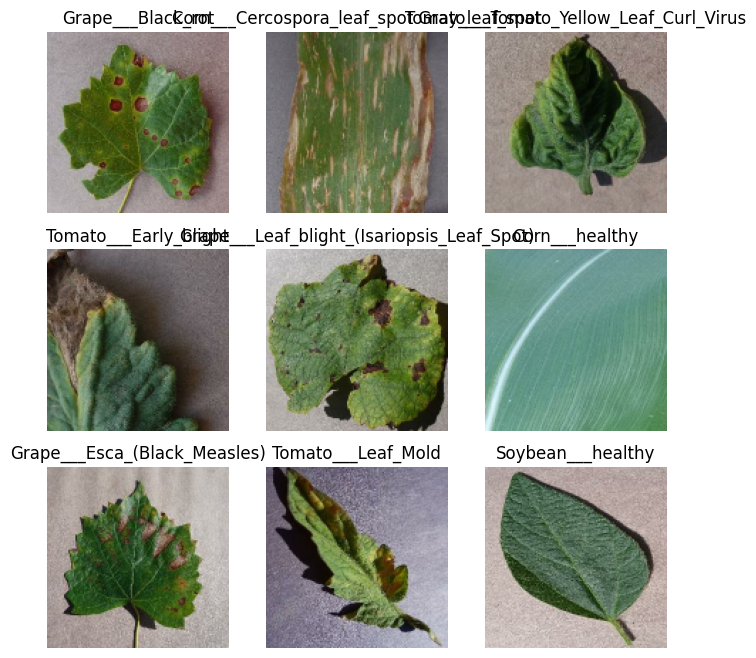

In [ ]:
plt.figure(figsize=(8, 8))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

prediction_layer = tf.keras.layers.Dense(39, activation='softmax')  # FIXED

inputs = tf.keras.Input(shape=(128, 128, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
initial_epochs = 2

history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=val_dataset
)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 224s 710ms/step - accuracy: 0.7257 - loss: 1.0256 - val_accuracy: 0.8919 - val_loss: 0.3978
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 175s 583ms/step - accuracy: 0.9064 - loss: 0.3254 - val_accuracy: 0.9200 - val_loss: 0.2883


In [ ]:
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

fine_tune_epochs = 2

history_fine = model.fit(
    train_dataset,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_dataset
)

Epoch 2/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.5257 - loss: 1.8008 - val_accuracy: 0.8825 - val_loss: 0.3941
Epoch 3/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 284s 947ms/step - accuracy: 0.8491 - loss: 0.5004 - val_accuracy: 0.8972 - val_loss: 0.3312
Epoch 4/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.9194 - loss: 0.2944 - val_accuracy: 0.9166 - val_loss: 0.2759


In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print("Test accuracy:", accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 94s 487ms/step - accuracy: 0.9146 - loss: 0.2671
Test accuracy: 0.914559006690979


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


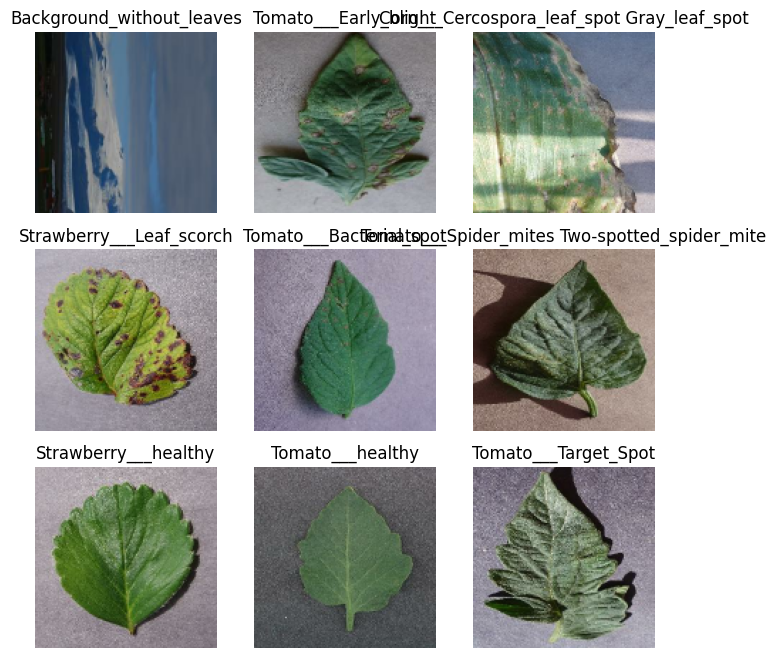

In [ ]:
image_batch, label_batch = next(iter(test_dataset))

predictions = model.predict(image_batch)
predicted_classes = tf.argmax(predictions, axis=1)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[predicted_classes[i]])
    plt.axis("off")

In [ ]:
model.save("plant_disease_model.keras")
import json
with open("class_names.json", "w") as f:
  json.dump(class_names, f)
print("Saved!")

Saved!
